In [1]:
from PyUltraLight2.Utils.IO import Data
import matplotlib.pyplot as plt
import numpy as np

In [14]:
data = Data("/Volumes/FWS500/PyULAlan_SP/")

# Still need N Body Energy Reconstruction

3D saves are not automatically loaded. Please load them manually!
['Energy', '1Density', 'NBody', '1GravF']
Loaded 44 Data Entries from /Volumes/FWS500/PyULAlan_SP/!
Did the run end early?


In [15]:
Density = data.Loaded["1Density"]
Phi = data.Loaded["1GravF"]

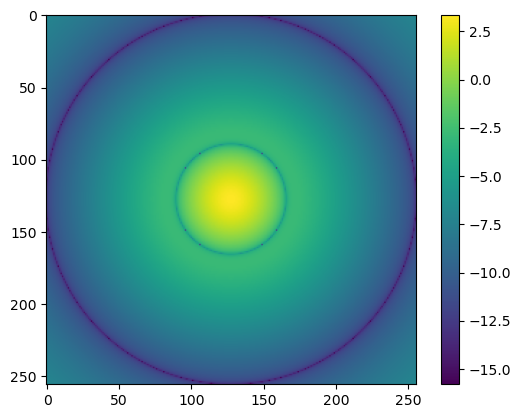

In [16]:
# External Psi

PsiExt = np.load("./Init_MMA_0.05(1,0,0)_50_256_psi.npy")

RhoExt = np.log10((PsiExt ** 2).real)

plt.imshow(RhoExt[:,:,128])
plt.colorbar()

PsiSc = np.sqrt(np.pi) * 2 * PsiExt

np.save("./Sca_psi.npy", PsiSc)

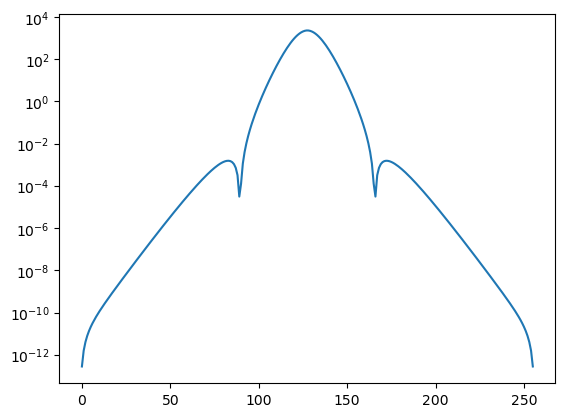

In [17]:
PsiExt = np.load("./Init_MMA_0.05(1,0,0)_50_256_psi.npy")

RhoExt = ((PsiExt ** 2).real)

plt.semilogy(RhoExt[:,128,128])


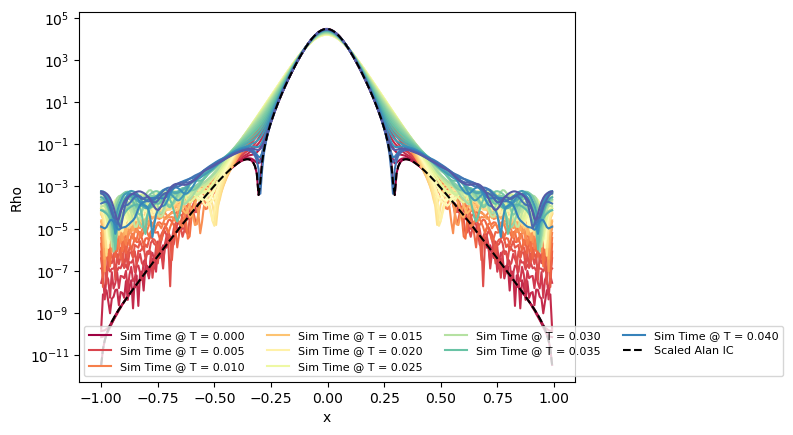

In [18]:
plt.figure()
for i in range(data.EndNum):
    color = plt.cm.Spectral(i/data.EndNum)

    if i % 5 ==0:
        plt.plot(data.xAr, Density[i], color = color, label = f"Sim Time @ T = {data.Tp[i]:.3f}")
    else:
        plt.plot(data.xAr, Density[i], color = color)
    

plt.semilogy(data.xAr, RhoExt[:,128,128] * 4 * np.pi,"k--", label = "Scaled Alan IC")

plt.ylabel("Rho")
plt.xlabel("x")

plt.legend(ncols = 4, fontsize = 8)

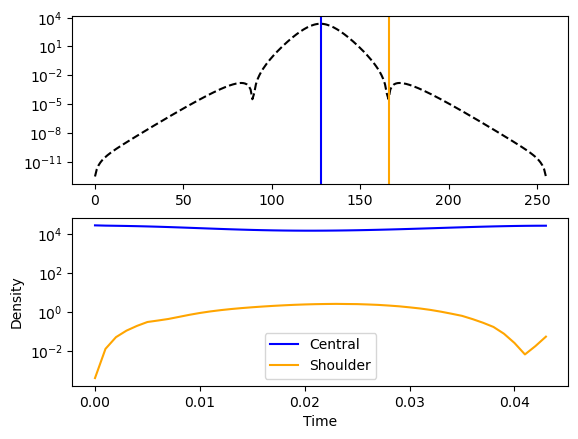

In [19]:
CentralDens =np.array( [rho[128] for rho in data.Loaded["1Density"]] )

ShoulderDens =np.array( [rho[166] for rho in data.Loaded["1Density"]] )


fig,axs = plt.subplots(nrows = 2)

axs[0].semilogy(RhoExt[:,128,128], "k--")
axs[0].axvline(166, label = "shoulder", color = "orange")
axs[0].axvline(128, label = "core", color = "blue")


axs[1].semilogy(data.Tp, CentralDens, label = "Central", color = "blue")
axs[1].plot(data.Tp, ShoulderDens, label = "Shoulder", color = "orange")


plt.xlabel("Time")
plt.ylabel("Density")

plt.legend()


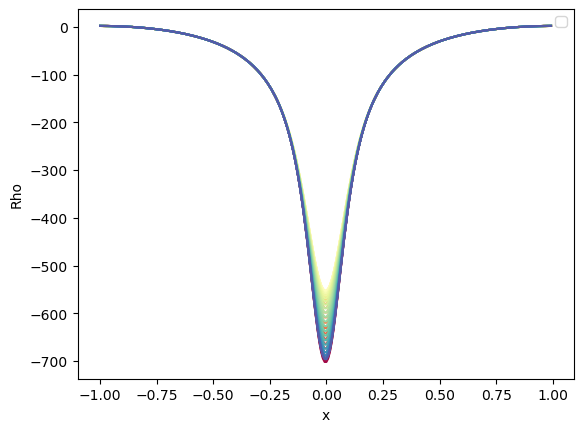

In [20]:
plt.figure()
for i in range(data.EndNum):
    color = plt.cm.Spectral(i/data.EndNum)
    plt.plot(data.xAr, Phi[i], color = color)

plt.ylabel("Rho")
plt.xlabel("x")

plt.legend()

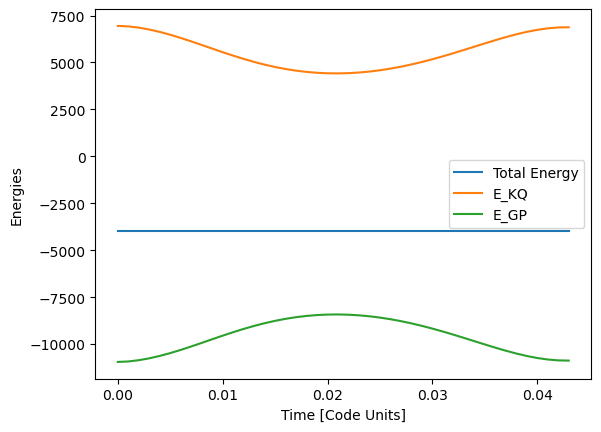

In [21]:
plt.figure()

plt.plot(data.Tp, data.ETotal, label = "Total Energy")
plt.plot(data.Tp, data.EKQ, label = "E_KQ")
plt.plot(data.Tp, data.EGP_UL, label = "E_GP")

plt.xlabel("Time [Code Units]")
plt.ylabel("Energies")

plt.legend()

In [10]:
data.config.ULDStepEst()

1030

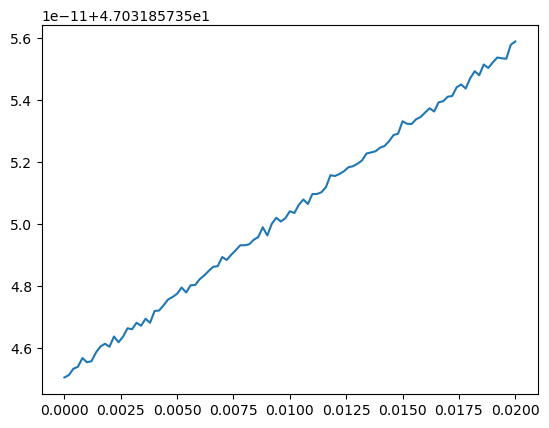

In [11]:
plt.plot(data.Tp, data.mTotal, label = "Total Simulated Mass")

In [12]:
data.Universe.convert(2.88,"M_solar_masses","m").si

<Quantity 40.8896627>

In [13]:
import numpy as np
import yt
from yt.visualization.volume_rendering.api import PointSource

# === CONFIGURATION ===
base_path = "/Volumes/FWS500/PyULAlan/Outputs/3Wfn"
file_prefix = "P3D_#"
file_range = range(0, 21)  # Files from 0 to 20
field_name = "density"  # This is the name that yt will use

# === LOAD DATASETS ===
datasets = []

for i in file_range:
    path = f"{base_path}/{file_prefix}{i:03d}.npy"
    
    try:
        array = np.load(path)
    except FileNotFoundError:
        print(f"Missing file: {path}")
        continue

    # Convert to real density (optional depending on data format)
    data = np.abs(array)**2 if np.iscomplexobj(array) else array

    # Build a YT dataset with unit dimensions (you can set `bbox` if needed)
    ds = yt.load_uniform_grid({field_name: data}, data.shape, length_unit="code_length")
    datasets.append(ds)

print(f"{len(datasets)} datasets loaded successfully.")

# === CREATE SCENE FROM LAST FRAME ===
if not datasets:
    raise RuntimeError("No datasets loaded; aborting visualization.")

ds = datasets[-1]
scene = yt.create_scene(ds, field=field_name)

# === CAMERA SETTINGS ===
cam = scene.add_camera(ds, lens_type="plane-parallel")
cam.resolution = [800, 800]

# === TRANSFER FUNCTION SETTINGS ===
source = scene[0]
source.tfh.set_bounds((data.min(), data.max()))
source.tfh.set_log(True)
source.tfh.grey_opacity = True

# === ANNOTATIONS ===
scene.annotate_axes()
# scene.annotate_grids(ds)
# scene.annotate_domain(ds, color=[1, 1, 1, 0.05])

# === SHOW OR SAVE ===
scene.show()  # Or scene.save("render.png", sigma_clip=8)

yt : [INFO     ] 2025-06-27 17:36:53,980 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-06-27 17:36:53,980 Parameters: domain_dimensions         = [256 256 256]
yt : [INFO     ] 2025-06-27 17:36:53,980 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-06-27 17:36:53,981 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-06-27 17:36:53,981 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-06-27 17:36:54,745 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-06-27 17:36:54,745 Parameters: domain_dimensions         = [256 256 256]
yt : [INFO     ] 2025-06-27 17:36:54,745 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-06-27 17:36:54,746 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-06-27 17:36:54,746 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-06-27 17:36:55,477 Parameters: current_time              = 0.0
yt : [INFO     ] 2025

KeyboardInterrupt: 

In [ ]:
import numpy as np
import yt
import os
from yt.visualization.volume_rendering.api import PointSource

# === CONFIGURATION ===
base_path = "/Volumes/FWS500/PyULAlan/Outputs/3Wfn"
file_prefix = "P3D_#"
file_range = range(0, 21)
field_name = "density"
output_dir = "frames"
os.makedirs(output_dir, exist_ok=True)


# === RENDER EACH FRAME ===
for i in file_range:
    path = f"{base_path}/{file_prefix}{i:03d}.npy"
    try:
        array = np.load(path)
    except FileNotFoundError:
        print(f"File not found: {path}")
        continue

    data = np.abs(array)**2 if np.iscomplexobj(array) else array
    ds = yt.load_uniform_grid({field_name: data}, data.shape, length_unit="code_length")

    # === SCENE ===
    scene = yt.create_scene(ds, field=field_name)

    # Set camera and resolution
    cam = scene.add_camera(ds, lens_type="plane-parallel")
    cam.resolution = [1200, 1200]

    # Set shared transfer function
    source = scene[0]
    source.tfh.set_bounds((1e-7, 2e4))
    source.tfh.set_log(True)
    source.tfh.grey_opacity = True

    # Optional point sources
    # vertices = np.array([[0.5, 0.5, 0.5]])
    # colors = np.array([[1, 1, 1, 0.95]])
    # points = PointSource(vertices, colors, radii=2)
    # scene.add_source(points)

    # === SAVE FRAME ===
    frame_file = os.path.join(output_dir, f"frame_{i:03d}.png")
    scene.save(frame_file, sigma_clip=6)
    print(f"Saved: {frame_file}")